In [1]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
# Load Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()



In [3]:
# Create DataFrame with numeric features
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("Original Dataset:")
print(df.head())



Original Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
# --------------------------------------------------
# 1. DATA CLEANING: Identify Missing Values
# --------------------------------------------------

print("\nMissing Values Before Filling:")
print(df.isnull().sum())

# Fill missing values using column mean
df.fillna(df.mean(), inplace=True)

print("\nMissing Values After Filling:")
print(df.isnull().sum())




Missing Values Before Filling:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Missing Values After Filling:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [5]:

# --------------------------------------------------
# 2. DATA REDUCTION: Identify Correlated Features
# --------------------------------------------------

# Calculate correlation matrix
correlation_matrix = df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)




Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [6]:
# Identify highly correlated feature pairs
print("\nHighly Correlated Features:")

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) > 0.7:
            print(
                correlation_matrix.columns[i],
                "<--->",
                correlation_matrix.columns[j],
                ":",
                round(correlation, 2)
            )



Highly Correlated Features:
sepal length (cm) <---> petal length (cm) : 0.87
sepal length (cm) <---> petal width (cm) : 0.82
petal length (cm) <---> petal width (cm) : 0.96


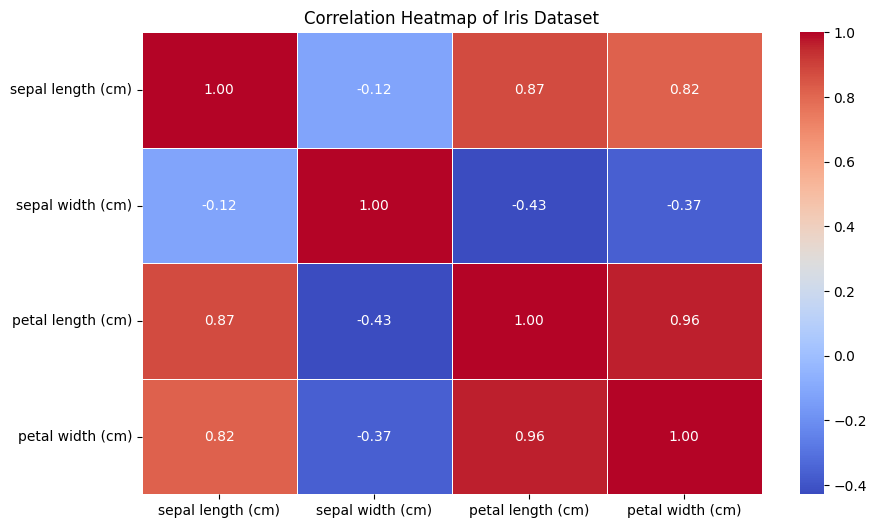

In [7]:
# --------------------------------------------------
# 3. VISUALIZE CORRELATION HEATMAP
# --------------------------------------------------

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Iris Dataset")
plt.show()